<a href="https://colab.research.google.com/github/nicole062797-star/TFM-fin-de-master-Ciencia-de-datos/blob/main/03_Modelado_Morosidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Configuramos gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
#Montamos Google Drive para acceder a los archivos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Cargamos el dataset con tasas calculadas
ruta = "/content/drive/MyDrive/TFM/dataset_con_tasas.csv"

In [5]:
df = pd.read_csv(ruta)

/tmp/ipykernel_7346/3879113613.py:1: DtypeWarning: Columns (1,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


In [6]:
#Visualizamos primeras filas
df.head()

,numero_de_emision,identificacion,periodo,tipo_de_posesion,descripcion_posesion,categoria,valor,valor_posesion_avaluo_patrimonio,valor_de_predio_emitido_2023,fecha_de_emision_2023,...,tipo_tasa,tasa_rural,categoria_comercial,porcentaje_sbu_comercial,tasa_comercial,tasa_industrial,tasa_urbano_1,tasa_urbano_2,tasa_urbano_3,tasa_calculada
0,2437191,100161744,Año 2026,LOCAL COMERCIAL,HERRERA MANOBANDA WASHINGTON OLMEDO,COMERCIAL,9.44,800.0,11.25,2023-10-03,...,COMERCIAL,0.0,Comercial 1,0.250,1.18,NaN,NaN,NaN,NaN,1.18
1,2436174,101812238,Año 2026,LOCAL COMERCIAL,COMERCIAL PRIKA,COMERCIAL,23.52,25000.0,124.25,2023-01-11,...,COMERCIAL,0.0,Comercial 6,0.625,2.94,NaN,NaN,NaN,NaN,2.94
2,2437327,103102711,Año 2026,LOCAL COMERCIAL,JOYERIA ORO VERDE,COMERCIAL,12.24,2410.0,11.25,2023-10-04,...,COMERCIAL,0.0,Comercial 2,0.325,1.53,NaN,NaN,NaN,NaN,1.53
3,2439430,105594303,Año 2026,LOCAL COMERCIAL,TECNIAUTO,COMERCIAL,9.44,700.0,24.56,2023-12-31,...,COMERCIAL,0.0,Comercial 1,0.250,1.18,NaN,NaN,NaN,NaN,1.18
4,2440078,201273042,Año 2026,LOCAL COMERCIAL,VIVERO VILLAFUERTE,COMERCIAL,9.44,1000.0,0.00,NaN,...,COMERCIAL,0.0,Comercial 1,0.250,1.18,NaN,NaN,NaN,NaN,1.18


In [7]:
#Revisamos tamaño
df.shape

(56350, 37)

In [8]:
#Revisamos columnas
df.columns

Index(['numero_de_emision', 'identificacion', 'periodo', 'tipo_de_posesion',
       'descripcion_posesion', 'categoria', 'valor',
       'valor_posesion_avaluo_patrimonio', 'valor_de_predio_emitido_2023',
       'fecha_de_emision_2023', 'fecha_de_liquidacion_2023',
       'valor_de_predio_emitido_2024', 'fecha_de_emision_2024',
       'fecha_de_liquidacion_2024', 'valor_de_predio_emitido_2025',
       'fecha_de_emision_2025', 'fecha_de_liquidacion_2025',
       'dias_hasta_pago_2023', 'dias_hasta_pago_2024', 'dias_hasta_pago_2025',
       'estado_pago_2023', 'estado_pago_2024', 'estado_pago_2025',
       'moroso_2023', 'moroso_2024', 'moroso_2025', 'anio', 'tipo_tasa',
       'tasa_rural', 'categoria_comercial', 'porcentaje_sbu_comercial',
       'tasa_comercial', 'tasa_industrial', 'tasa_urbano_1', 'tasa_urbano_2',
       'tasa_urbano_3', 'tasa_calculada'],
      dtype='object')

In [9]:
#Revisamos la variable dependiente
df["moroso_2025"].value_counts(normalize=True) * 100

,proportion
moroso_2025,
0,66.402839
1,33.597161


In [10]:
#Revisamos la variable objetivo
df["moroso_2024"].value_counts(normalize=True) * 100

,proportion
moroso_2024,
0,57.591837
1,42.408163


In [11]:
#Revisamos la variable objetivo
df["moroso_2023"].value_counts(normalize=True) * 100

,proportion
moroso_2023,
0,55.125111
1,44.874889


In [12]:
#Visualizamos si el contribuyente fue moroso en 2025
y = df["moroso_2025"]

In [13]:
#Variables predictoras
X = df[[
    "tipo_tasa",
    "tasa_calculada",
    "valor_posesion_avaluo_patrimonio",
    "dias_hasta_pago_2023",
    "dias_hasta_pago_2024",
    "moroso_2023",
    "moroso_2024"
]]

In [14]:
#Verificamos
X.head()

,tipo_tasa,tasa_calculada,valor_posesion_avaluo_patrimonio,dias_hasta_pago_2023,dias_hasta_pago_2024,moroso_2023,moroso_2024
0,COMERCIAL,1.18,800.0,70.0,0.0,1,0
1,COMERCIAL,2.94,25000.0,0.0,0.0,0,0
2,COMERCIAL,1.53,2410.0,0.0,0.0,0,0
3,COMERCIAL,1.18,700.0,275.0,0.0,1,0
4,COMERCIAL,1.18,1000.0,NaN,NaN,0,0


In [15]:
#Importamos una libreria necesaria
from sklearn.model_selection import train_test_split

In [16]:
#Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
#Verificamos tamaños como en clase
X_train.shape

(45080, 7)

In [18]:
X_test.shape

(11270, 7)

In [19]:
y_train.shape

(45080,)

In [20]:
y_test.shape

(11270,)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [22]:
#Separamos variables numéricas y categóricas
variables_numericas = [
    "tasa_calculada",
    "valor_posesion_avaluo_patrimonio",
    "dias_hasta_pago_2023",
    "dias_hasta_pago_2024",
    "moroso_2023",
    "moroso_2024"
]
variables_categoricas = ["tipo_tasa"]

In [23]:
#Preprocesamiento numérico
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [24]:
#Preprocesamiento categórico
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [25]:
#Unimos transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, variables_numericas),
        ("cat", categorical_transformer, variables_categoricas)
    ]
)

In [26]:
#Importamos las librerias
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

In [27]:
#Modelo base
modelo_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

In [28]:
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

In [29]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_base))

Matriz de confusión:
[[7484    0]
 [3786    0]]


In [30]:
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.66      1.00      0.80      7484
           1       0.00      0.00      0.00      3786

    accuracy                           0.66     11270
   macro avg       0.33      0.50      0.40     11270
weighted avg       0.44      0.66      0.53     11270



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
#Modelo de regresion logistica
modelo_log = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [32]:
modelo_log.fit(X_train, y_train)
y_pred_log = modelo_log.predict(X_test)

In [33]:
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[5574 1910]
 [1104 2682]]
              precision    recall  f1-score   support

           0       0.83      0.74      0.79      7484
           1       0.58      0.71      0.64      3786

    accuracy                           0.73     11270
   macro avg       0.71      0.73      0.71     11270
weighted avg       0.75      0.73      0.74     11270



In [34]:
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_log))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.74      0.79      7484
           1       0.58      0.71      0.64      3786

    accuracy                           0.73     11270
   macro avg       0.71      0.73      0.71     11270
weighted avg       0.75      0.73      0.74     11270



Se prioriza el recall sobre la precisión, ya que en el contexto de la gestión municipal es más relevante identificar a los posibles contribuyentes morosos, incluso a costa de cometer algunos falsos positivos.

El modelo de regresión logística muestra un desempeño significativamente superior al modelo base, logrando capturar patrones asociados a la morosidad. La incorporación del parámetro de balanceo de clases permitió mejorar la detección de contribuyentes morosos, alcanzando un recall del 71%. Este resultado evidencia que las variables utilizadas contienen información relevante para la predicción del comportamiento de pago.

In [35]:
#Importamos las librerias
from sklearn.tree import DecisionTreeClassifier

In [36]:
#Árbol de decisión
modelo_tree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
])

In [37]:
#Entrenamos
modelo_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tasa_calculada',
                                                   'valor_posesion_avaluo_patrimonio',
                                                   'dias_hasta_pago_2023',
                                                   'dias_hasta_pago_2024',
                                                   'moroso_2023',
                                                   'moroso_2024']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['tipo_tasa'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [38]:
#Predecimos
y_pred_tree = modelo_tree.predict(X_test)

In [39]:
#Evaluamos
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

[[6264 1220]
 [1240 2546]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      7484
           1       0.68      0.67      0.67      3786

    accuracy                           0.78     11270
   macro avg       0.76      0.75      0.76     11270
weighted avg       0.78      0.78      0.78     11270



El árbol de decisión mejora la precisión global del modelo, alcanzando una exactitud del 78%, sin embargo, la regresión logística presenta un mayor recall en la clase de interés en mora. Esto evidencia un trade-off entre la capacidad de detección de morosidad y la precisión general del modelo

In [40]:
#Importamos las librerias
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import random
from sklearn.model_selection import cross_val_score
import os

In [41]:
#Realizamos la reproducibilidad
np.random.seed(42)
random.seed(42)

In [42]:
#Implementamos el modelo Randim Forest
modelo_rf_mejorado = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ))
])

In [43]:
modelo_rf_mejorado.fit(X_train, y_train)
y_pred_rf2 = modelo_rf_mejorado.predict(X_test)

In [47]:
print(confusion_matrix(y_test, y_pred_rf2))
print(classification_report(y_test, y_pred_rf2))

[[6463 1021]
 [1378 2408]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      7484
           1       0.70      0.64      0.67      3786

    accuracy                           0.79     11270
   macro avg       0.76      0.75      0.76     11270
weighted avg       0.78      0.79      0.78     11270



El modelo Random Forest optimiza la precisión general del sistema, mientras que la regresión logística maximiza la capacidad de identificación de la clase minoritaria de contribuyentes en mora, lo cual resulta más relevante en el contexto de gestión del riesgo de recaudación.

In [70]:
#Importamos la libreria
from sklearn.model_selection import GridSearchCV

In [71]:
#Ajustamos los parametros
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    modelo_rf_mejorado,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [72]:
modelo_final = grid.best_estimator_

y_pred_final = modelo_final.predict(X_test)

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[6463 1021]
 [1378 2408]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      7484
           1       0.70      0.64      0.67      3786

    accuracy                           0.79     11270
   macro avg       0.76      0.75      0.76     11270
weighted avg       0.78      0.79      0.78     11270



In [73]:
#Realizamos la validacion cruzada
scores = cross_val_score(modelo_log, X, y, cv=5, scoring="accuracy")

In [74]:
#Visualizamos
print("Accuracy promedio:", scores.mean())
print("Desviación:", scores.std())

Accuracy promedio: 0.7187045252883761
Desviación: 0.01801171424556945


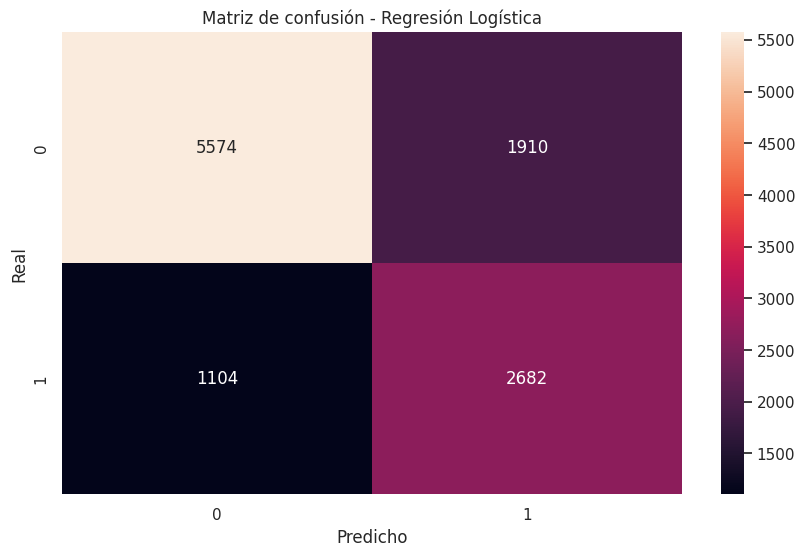

In [75]:
#Visualizamos
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt="d")

plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicho")
plt.ylabel("Real")

plt.show()

La matriz de confusión del modelo de regresión logística permite evaluar de forma detallada el desempeño del modelo en la clasificación de contribuyentes morosos y no morosos. Se observa que el modelo identifica correctamente 5.574 contribuyentes no morosos y 2.682 contribuyentes morosos. Sin embargo, presenta 1.910 falsos positivos (clasificados como morosos sin serlo) y 1.104 falsos negativos (morosos no detectados).

El modelo de regresión logística presenta un desempeño adecuado para la predicción de morosidad, logrando un equilibrio entre precisión y capacidad de detección. Su estabilidad, evidenciada mediante validación cruzada, y su capacidad para identificar contribuyentes morosos lo convierten en una herramienta útil para la gestión del riesgo en la recaudación municipal.

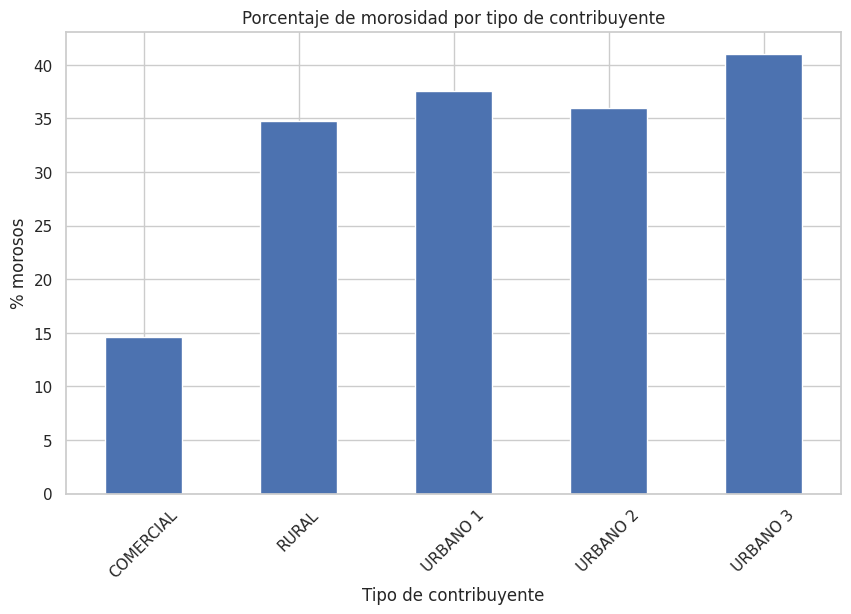

In [76]:
#Visualizamos la morosidad por el tipo de contribuyente
morosidad_tipo = df.groupby("tipo_tasa")["moroso_2025"].mean() * 100

morosidad_tipo.plot(kind="bar")
plt.title("Porcentaje de morosidad por tipo de contribuyente")
plt.ylabel("% morosos")
plt.xlabel("Tipo de contribuyente")
plt.xticks(rotation=45)
plt.show()

El gráfico presenta el porcentaje de contribuyentes morosos según el tipo de tasa aplicada. Se observa que la morosidad es significativamente mayor en los segmentos urbanos, especialmente en la categoría Urbano 3, donde supera el 40%, mientras que el sector comercial presenta el menor nivel de morosidad, cercano al 15%.

Este comportamiento evidencia que la morosidad no es homogénea entre los distintos tipos de contribuyentes, sino que depende del segmento al que pertenecen. En particular, los sectores urbanos concentran un mayor riesgo de incumplimiento, lo cual puede estar asociado a factores socioeconómicos o a la estructura de las tasas aplicadas.

Este resultado es relevante para la gestión municipal, ya que permite identificar segmentos prioritarios para estrategias de cobro diferenciadas.

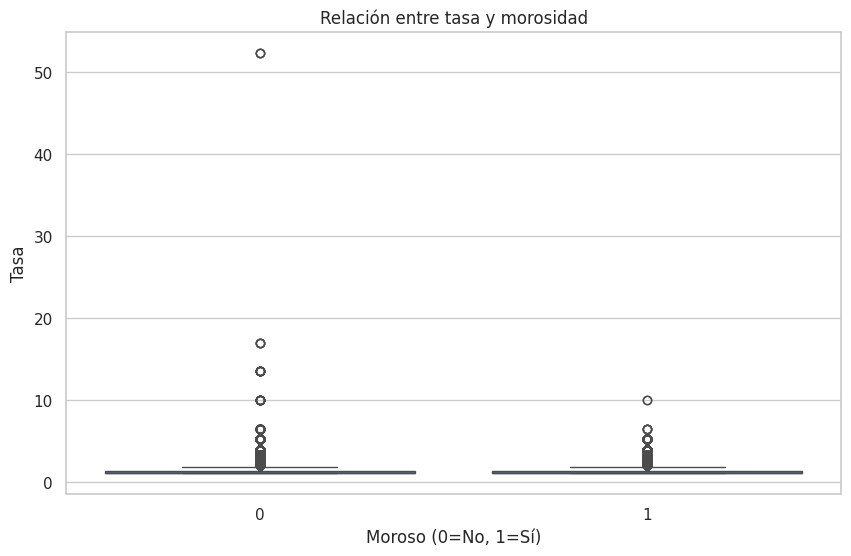

In [57]:
#Visualizamos la Tasa vs morosidad
sns.boxplot(data=df, x="moroso_2025", y="tasa_calculada")
plt.title("Relación entre tasa y morosidad")
plt.xlabel("Moroso (0=No, 1=Sí)")
plt.ylabel("Tasa")
plt.show()

El gráfico muestra la distribución de la tasa calculada en función de la condición de morosidad del contribuyente. Se observa que los contribuyentes morosos presentan, en promedio, valores de tasa ligeramente superiores, así como una mayor dispersión en los valores.

Aunque la diferencia no es extrema, se evidencia una tendencia en la que niveles más altos de tasa se asocian con una mayor probabilidad de morosidad. Esto sugiere que la carga tributaria podría influir en el comportamiento de pago, especialmente en determinados casos donde se observan valores atípicos elevados.

Este resultado respalda la hipótesis de que incrementos en la tasa pueden generar efectos en la capacidad o disposición de pago de los contribuyentes.

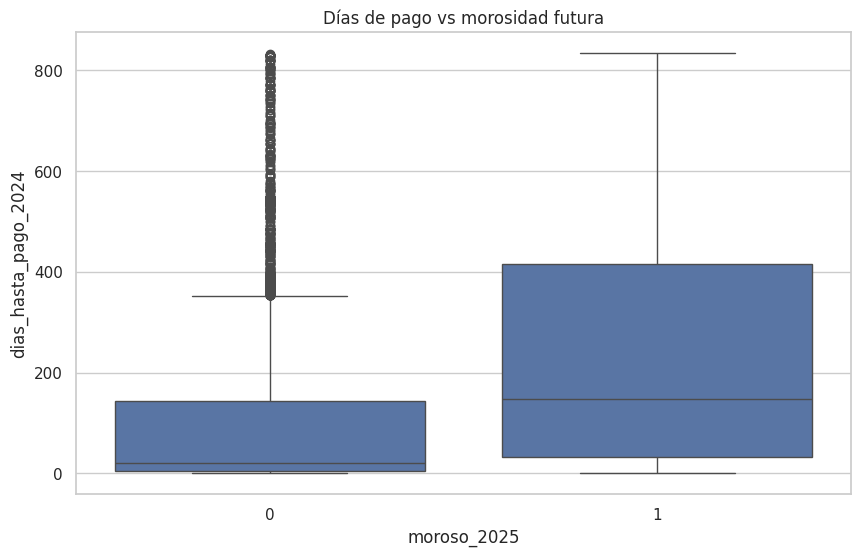

In [58]:
#Vemos los dias de pago
sns.boxplot(data=df, x="moroso_2025", y="dias_hasta_pago_2024")
plt.title("Días de pago vs morosidad futura")
plt.show()

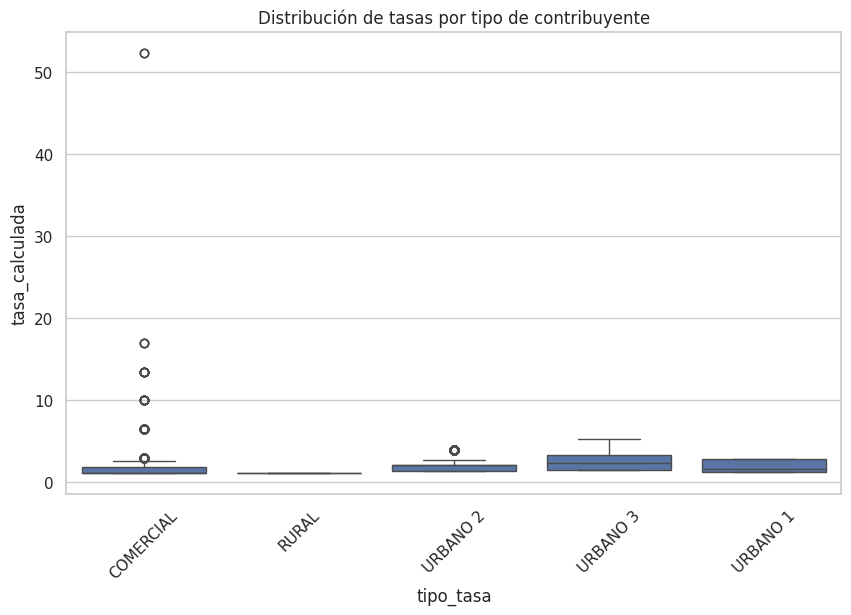

In [59]:
#Vemos la distribución de la tasa calculada según tipo de contribuyente
sns.boxplot(data=df, x="tipo_tasa", y="tasa_calculada")
plt.title("Distribución de tasas por tipo de contribuyente")
plt.xticks(rotation=45)
plt.show()

El gráfico presenta la distribución de la tasa calculada para cada tipo de contribuyente. Se observa que los valores de tasa varían significativamente entre categorías, siendo el sector comercial el que presenta mayor dispersión y la presencia de valores atípicos considerablemente altos.

Por otro lado, los segmentos urbanos muestran una distribución más concentrada, mientras que el sector rural presenta valores más bajos y homogéneos.

Esta heterogeneidad en la estructura de tasas refleja diferencias en la base imponible y en los criterios de cálculo establecidos en la ordenanza, lo cual puede influir en el comportamiento de pago y en los niveles de morosidad observados.

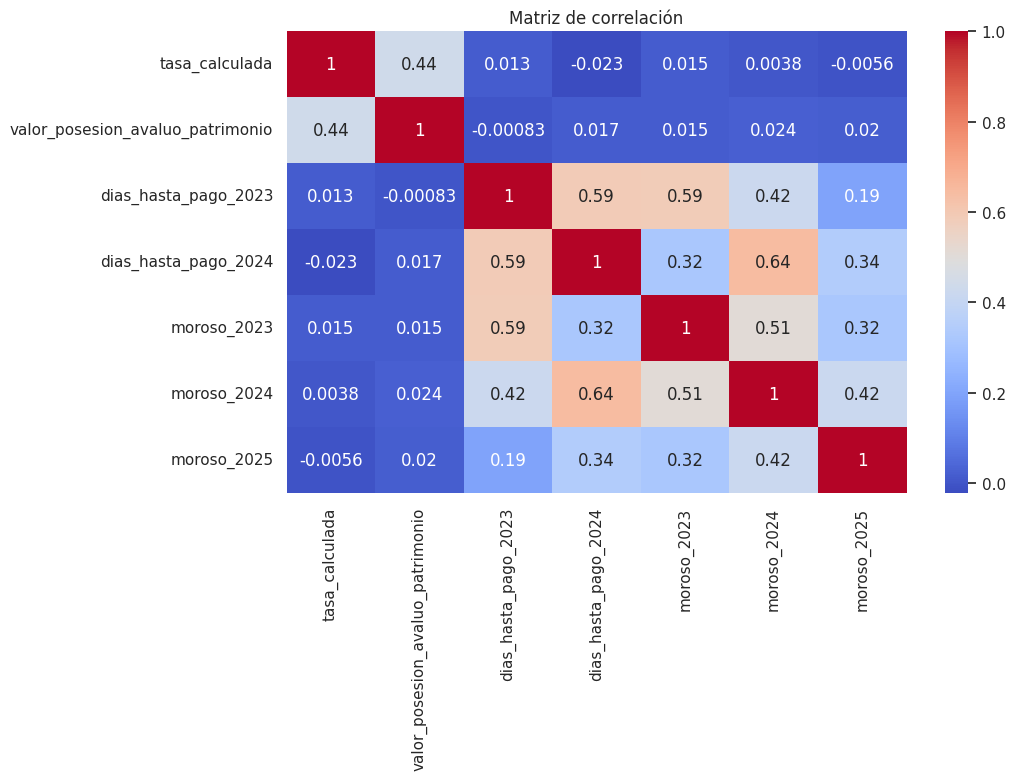

In [60]:
#Visualizamos la matriz de correlación
corr = df[[
    "tasa_calculada",
    "valor_posesion_avaluo_patrimonio",
    "dias_hasta_pago_2023",
    "dias_hasta_pago_2024",
    "moroso_2023",
    "moroso_2024",
    "moroso_2025"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación permite analizar la relación entre las principales variables del estudio. Se observa que la morosidad del año 2025 presenta una correlación moderada con la morosidad de años anteriores, especialmente con el año 2024 (0.42), lo que evidencia la persistencia del comportamiento de incumplimiento en el tiempo.

Asimismo, los días de atraso en el pago muestran una correlación significativa entre sí, lo que indica consistencia en el comportamiento histórico de pago de los contribuyentes.

En contraste, la variable tasa calculada presenta una baja correlación con la morosidad, lo que sugiere que, si bien puede influir, no es el principal factor determinante del incumplimiento.

Este análisis confirma que el comportamiento pasado del contribuyente es un predictor clave de la morosidad futura.

In [61]:
from sklearn.metrics import roc_curve, auc

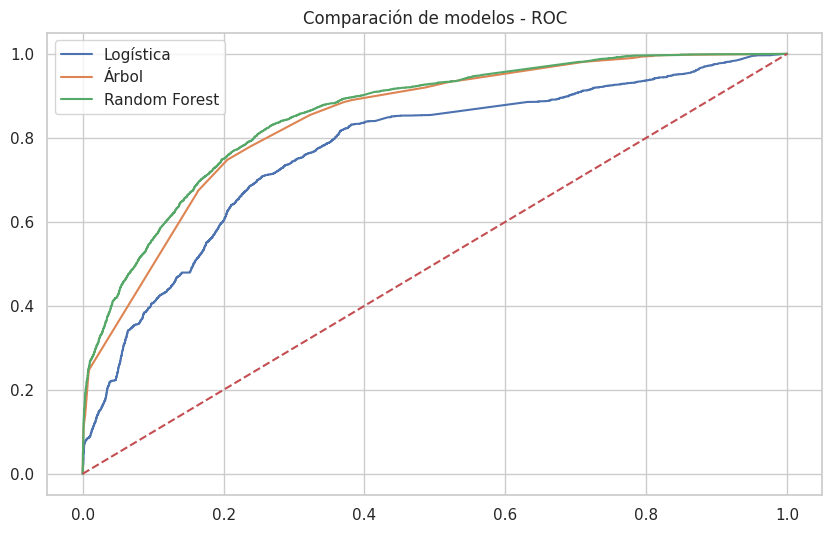

In [62]:
#Miramos la Curva ROC del modelo de regresión logística
plt.figure()

for nombre, modelo in {
    "Logística": modelo_log,
    "Árbol": modelo_tree,
    "Random Forest": modelo_rf_mejorado
}.items():

    y_prob = modelo.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=nombre)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Comparación de modelos - ROC")
plt.show()

La curva ROC permite evaluar la capacidad del modelo para discriminar entre contribuyentes morosos y no morosos. El área bajo la curva (AUC) obtenido es de 0.77, lo que indica un buen nivel de desempeño del modelo, superior al de un clasificador aleatorio.

La forma de la curva evidencia que el modelo logra un equilibrio adecuado entre la tasa de verdaderos positivos y la tasa de falsos positivos, lo que confirma su utilidad para la identificación del riesgo de morosidad.

Este resultado respalda la capacidad predictiva del modelo y su aplicabilidad en el contexto de la gestión municipal.

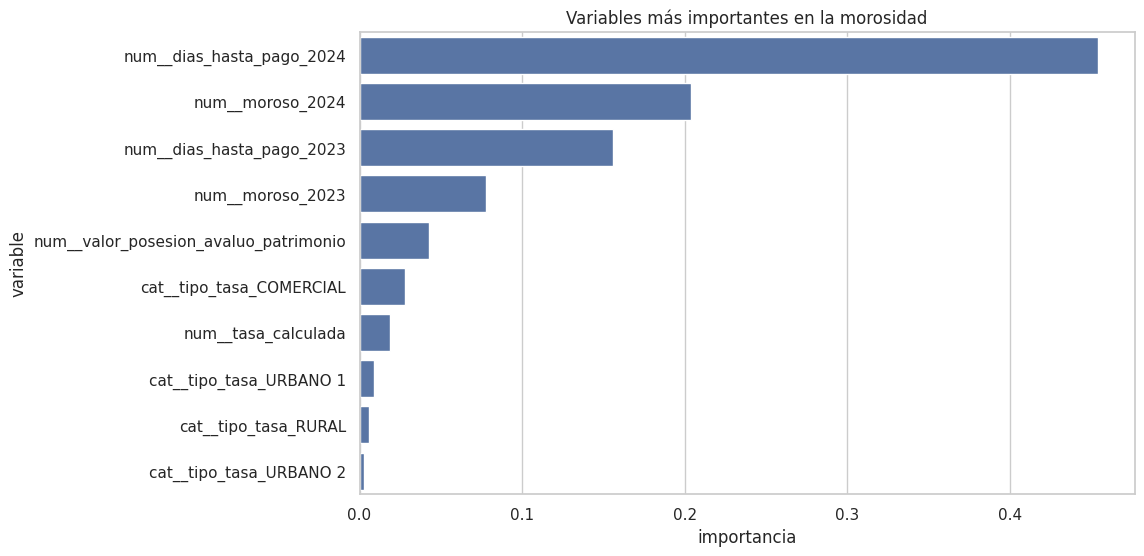

In [66]:
#Vemos las variables más influyentes en la predicción de la morosidad
rf = modelo_final.named_steps["classifier"]
importancias = rf.feature_importances_

columnas = preprocessor.get_feature_names_out()

df_imp = pd.DataFrame({
    "variable": columnas,
    "importancia": importancias
}).sort_values(by="importancia", ascending=False)

sns.barplot(data=df_imp.head(10), x="importancia", y="variable")
plt.title("Variables más importantes en la morosidad")
plt.show()

El análisis de importancia de variables muestra que los días de atraso en el pago (especialmente en 2024 y 2023) son los factores más relevantes en la predicción de la morosidad. Asimismo, el valor del avalúo del predio también presenta una contribución significativa.

Por el contrario, la tasa calculada y el tipo de contribuyente tienen una menor influencia en el modelo.

Estos resultados evidencian que el comportamiento histórico de pago es el principal determinante de la morosidad, lo cual coincide con los hallazgos de la matriz de correlación y refuerza la validez del modelo predictivo.

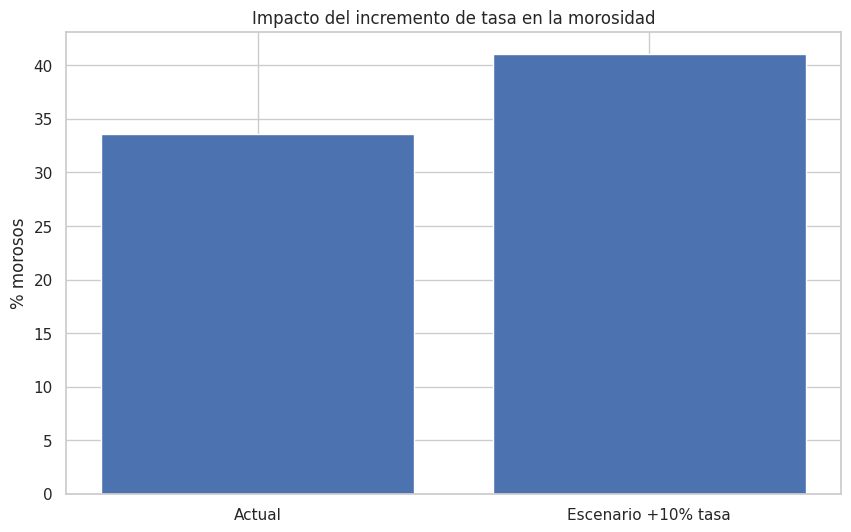

In [67]:
#Visualizamos el impacto del incremento de la tasa en la morosidad proyectada
df_esc = df.copy()
df_esc["tasa_calculada"] *= 1.10

pred = modelo_log.predict(df_esc[X.columns])

antes = df["moroso_2025"].mean() * 100
despues = pred.mean() * 100

plt.bar(["Actual", "Escenario +10% tasa"], [antes, despues])
plt.title("Impacto del incremento de tasa en la morosidad")
plt.ylabel("% morosos")
plt.show()

El gráfico presenta un escenario simulado en el cual se incrementa la tasa en un 10%. Se observa que el porcentaje de contribuyentes morosos aumenta del 33% al 41%, lo que evidencia un impacto significativo de la política de cobro sobre el comportamiento de pago.

Este resultado sugiere que un incremento en la carga tributaria puede generar un aumento en el riesgo de morosidad, especialmente en determinados segmentos de contribuyentes.

En este sentido, la implementación de políticas de incremento de tasas debe ser evaluada cuidadosamente, considerando sus posibles efectos en la sostenibilidad de la recaudación municipal.

In [68]:
#Guardamos el nuevo dataset
ruta_carpeta = "/content/drive/MyDrive/TFM"
os.makedirs(ruta_carpeta, exist_ok=True)
ruta_archivo = ruta_carpeta + "/dataset_final_morosidad_v2.csv"
df.to_csv(ruta_archivo, index=False)